# LSTM and GRU

## Learning Objectives

1. **Explain** why LSTM's cell state $c_t$ provides a direct gradient highway that avoids vanishing gradients
2. **Define** the four LSTM gates and their equations (forget $f_t$, input $i_t$, candidate $\tilde{c}_t$, output $o_t$)
3. **State** the GRU equations (update gate $z_t$, reset gate $r_t$, candidate $\tilde{h}_t$) and compare to LSTM
4. **Explain** why gated RNNs outperform vanilla RNNs on long-range dependencies
5. **Implement** an LSTM cell from scratch and verify forward pass


## Problem Statement

Vanilla RNNs struggle with long-range dependencies because gradients must flow through the tanh nonlinearity at every time step (see `ml_013_05`). LSTM (Hochreiter & Schmidhuber, 1997) and GRU (Cho et al., 2014) introduce **gating mechanisms** that control information flow, creating a gradient highway through time.

### LSTM Equations

The LSTM maintains two states: cell state $c_t$ (long-term memory) and hidden state $h_t$ (short-term memory).

$$f_t = \sigma(W_f [h_{t-1}; x_t] + b_f) \quad\text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}; x_t] + b_i) \quad\text{(input gate)}$$
$$\tilde{c}_t = \tanh(W_c [h_{t-1}; x_t] + b_c) \quad\text{(candidate cell)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad\text{(cell update)}$$
$$o_t = \sigma(W_o [h_{t-1}; x_t] + b_o) \quad\text{(output gate)}$$
$$h_t = o_t \odot \tanh(c_t) \quad\text{(hidden state)}$$

where $[h_{t-1}; x_t]$ denotes concatenation and $\odot$ is element-wise multiplication.

### GRU Equations

$$z_t = \sigma(W_z [h_{t-1}; x_t] + b_z) \quad\text{(update gate)}$$
$$r_t = \sigma(W_r [h_{t-1}; x_t] + b_r) \quad\text{(reset gate)}$$
$$\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}; x_t] + b_h) \quad\text{(candidate hidden)}$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t \quad\text{(hidden update)}$$

GRU has fewer parameters (no cell state, 3 weight matrices vs 4) but comparable performance on most tasks.


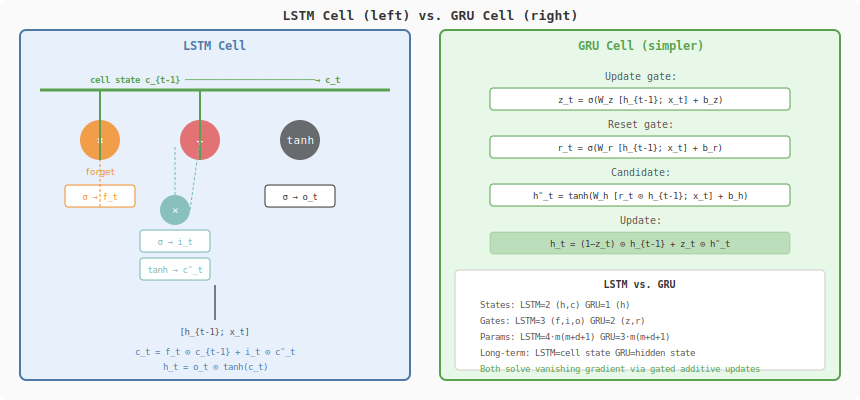

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="400" font-family="monospace" font-size="10">
  <rect width="860" height="400" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">LSTM Cell (left) vs. GRU Cell (right)</text>

  <!-- ── LSTM ── -->
  <rect x="20" y="30" width="390" height="350" rx="6" fill="#e8f0fb" stroke="#4e79a7" stroke-width="2"/>
  <text x="215" y="50" text-anchor="middle" fill="#4e79a7" font-size="12" font-weight="bold">LSTM Cell</text>

  <!-- Cell state (top highway) -->
  <line x1="40" y1="90" x2="390" y2="90" stroke="#59a14f" stroke-width="3"/>
  <text x="215" y="83" text-anchor="middle" fill="#59a14f" font-size="9" font-weight="bold">cell state  c_{t-1} ──────────────────────────→ c_t</text>

  <!-- Forget gate -->
  <circle cx="100" cy="140" r="20" fill="#f28e2b" opacity="0.85"/>
  <text x="100" y="144" text-anchor="middle" fill="#fff" font-size="11" font-weight="bold">×</text>
  <text x="100" y="175" text-anchor="middle" fill="#f28e2b" font-size="9">forget</text>
  <line x1="100" y1="90" x2="100" y2="120" stroke="#59a14f" stroke-width="2"/>
  <line x1="100" y1="160" x2="100" y2="90" stroke="#59a14f" stroke-width="2"/>
  <!-- sigmoid for forget -->
  <rect x="65" y="185" width="70" height="22" rx="3" fill="#fff" stroke="#f28e2b"/>
  <text x="100" y="200" text-anchor="middle" fill="#f28e2b" font-size="9">σ → f_t</text>
  <line x1="100" y1="207" x2="100" y2="160" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>

  <!-- Input gate -->
  <circle cx="200" cy="140" r="20" fill="#e05c5c" opacity="0.85"/>
  <text x="200" y="144" text-anchor="middle" fill="#fff" font-size="11" font-weight="bold">+</text>
  <line x1="200" y1="90" x2="200" y2="120" stroke="#59a14f" stroke-width="2"/>
  <line x1="200" y1="160" x2="200" y2="90" stroke="#59a14f" stroke-width="2"/>
  <!-- i_t * c~ -->
  <circle cx="175" cy="210" r="15" fill="#76b7b2" opacity="0.85"/>
  <text x="175" y="214" text-anchor="middle" fill="#fff" font-size="11">×</text>
  <line x1="175" y1="195" x2="175" y2="145" stroke="#76b7b2" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="190" y1="210" x2="200" y2="140" stroke="#76b7b2" stroke-width="1" stroke-dasharray="3,2"/>
  <rect x="140" y="230" width="70" height="22" rx="3" fill="#fff" stroke="#76b7b2"/>
  <text x="175" y="245" text-anchor="middle" fill="#76b7b2" font-size="9">σ → i_t</text>
  <rect x="140" y="258" width="70" height="22" rx="3" fill="#fff" stroke="#76b7b2"/>
  <text x="175" y="273" text-anchor="middle" fill="#76b7b2" font-size="9">tanh → c̃_t</text>

  <!-- Output gate -->
  <circle cx="300" cy="140" r="20" fill="#333" opacity="0.7"/>
  <text x="300" y="144" text-anchor="middle" fill="#fff" font-size="11">tanh</text>
  <!-- h_t = o * tanh(c_t) -->
  <rect x="265" y="185" width="70" height="22" rx="3" fill="#fff" stroke="#333"/>
  <text x="300" y="200" text-anchor="middle" fill="#333" font-size="9">σ → o_t</text>

  <!-- Inputs -->
  <line x1="215" y1="320" x2="215" y2="285" stroke="#555" stroke-width="1.5"/>
  <text x="215" y="335" text-anchor="middle" fill="#555" font-size="9">[h_{t-1}; x_t]</text>

  <!-- Equation summary -->
  <text x="215" y="355" text-anchor="middle" fill="#4e79a7" font-size="9">c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t</text>
  <text x="215" y="370" text-anchor="middle" fill="#4e79a7" font-size="9">h_t = o_t ⊙ tanh(c_t)</text>

  <!-- ── GRU ── -->
  <rect x="440" y="30" width="400" height="350" rx="6" fill="#e8f8e8" stroke="#59a14f" stroke-width="2"/>
  <text x="640" y="50" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">GRU Cell (simpler)</text>

  <text x="640" y="80" text-anchor="middle" fill="#555" font-size="10">Update gate:</text>
  <rect x="490" y="88" width="300" height="22" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="640" y="103" text-anchor="middle" fill="#333" font-size="9">z_t = σ(W_z [h_{t-1}; x_t] + b_z)</text>

  <text x="640" y="128" text-anchor="middle" fill="#555" font-size="10">Reset gate:</text>
  <rect x="490" y="136" width="300" height="22" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="640" y="151" text-anchor="middle" fill="#333" font-size="9">r_t = σ(W_r [h_{t-1}; x_t] + b_r)</text>

  <text x="640" y="176" text-anchor="middle" fill="#555" font-size="10">Candidate:</text>
  <rect x="490" y="184" width="300" height="22" rx="3" fill="#fff" stroke="#59a14f"/>
  <text x="640" y="199" text-anchor="middle" fill="#333" font-size="9">h̃_t = tanh(W_h [r_t ⊙ h_{t-1}; x_t] + b_h)</text>

  <text x="640" y="224" text-anchor="middle" fill="#555" font-size="10">Update:</text>
  <rect x="490" y="232" width="300" height="22" rx="3" fill="#59a14f" opacity="0.3" stroke="#59a14f"/>
  <text x="640" y="247" text-anchor="middle" fill="#333" font-size="9">h_t = (1−z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t</text>

  <!-- Comparison table -->
  <rect x="455" y="270" width="370" height="100" rx="4" fill="#fff" stroke="#ccc"/>
  <text x="640" y="288" text-anchor="middle" fill="#333" font-size="10" font-weight="bold">LSTM vs. GRU</text>
  <text x="480" y="308" fill="#555" font-size="9">States:     LSTM=2 (h,c)        GRU=1 (h)</text>
  <text x="480" y="324" fill="#555" font-size="9">Gates:      LSTM=3 (f,i,o)      GRU=2 (z,r)</text>
  <text x="480" y="340" fill="#555" font-size="9">Params:     LSTM=4·m(m+d+1)    GRU=3·m(m+d+1)</text>
  <text x="480" y="356" fill="#555" font-size="9">Long-term:  LSTM=cell state     GRU=hidden state</text>
  <text x="480" y="372" fill="#59a14f" font-size="9">Both solve vanishing gradient via gated additive updates</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Why LSTM Avoids Vanishing Gradients

The key is the **cell state update**:
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

This is an **additive** update (unlike the multiplicative tanh in vanilla RNN). The gradient of $c_T$ w.r.t. $c_0$ is:
$$\frac{\partial c_T}{\partial c_0} = \prod_{t=1}^T \text{diag}(f_t)$$

Since $f_t = \sigma(\cdot) \in (0,1)$ is a **learned gate**, the network can set $f_t \approx 1$ for time steps where memory should be preserved, maintaining gradients near 1 over long distances. The forget gate effectively controls the gradient flow — unlike the fixed tanh Jacobian in vanilla RNNs.

**Contrast with vanilla RNN:**
$$\frac{\partial s_T}{\partial s_0} = \prod_{t=1}^T \text{diag}(1-s_t^2) \cdot W$$
This product of matrices with spectral norm potentially $< 1$ causes vanishing.

### GRU's Update Gate

The GRU interpolation:
$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

when $z_t \approx 0$, $h_t \approx h_{t-1}$ — the state is copied unchanged, allowing gradients to flow back unchanged. When $z_t \approx 1$, the state is fully replaced.


In [2]:
import numpy as np


class LSTMCell:
    """Single LSTM cell."""

    def __init__(self, input_size, hidden_size, seed=0):
        rng = np.random.default_rng(seed)
        self.H = hidden_size
        self.D = input_size
        s = 0.1
        # Concatenated weight matrices [W_f, W_i, W_c, W_o] — each (H, H+D)
        self.W = rng.normal(0, s, (4 * hidden_size, hidden_size + input_size))
        self.b = np.zeros(4 * hidden_size)
        # Bias forget gate to 1 (helps long-range deps)
        self.b[:hidden_size] = 1.0

    @staticmethod
    def _sigmoid(z): return 1 / (1 + np.exp(-z))

    def forward(self, x, h_prev, c_prev):
        """Single time step. Returns (h_t, c_t, cache)."""
        combined = np.concatenate([h_prev, x])  # (H+D,)
        gates    = self.W @ combined + self.b    # (4H,)
        H = self.H
        f = self._sigmoid(gates[:H])
        i = self._sigmoid(gates[H:2*H])
        c_tilde  = np.tanh(gates[2*H:3*H])
        o = self._sigmoid(gates[3*H:])
        c = f * c_prev + i * c_tilde
        h = o * np.tanh(c)
        cache = (combined, f, i, c_tilde, o, c, c_prev, h_prev)
        return h, c, cache


class GRUCell:
    """Single GRU cell."""

    def __init__(self, input_size, hidden_size, seed=0):
        rng = np.random.default_rng(seed)
        self.H = hidden_size
        s = 0.1
        # [W_z, W_r] — each (H, H+D)
        self.Wzr = rng.normal(0, s, (2*hidden_size, hidden_size + input_size))
        self.bzr  = np.zeros(2*hidden_size)
        # W_h — (H, H+D)
        self.Wh  = rng.normal(0, s, (hidden_size, hidden_size + input_size))
        self.bh  = np.zeros(hidden_size)

    @staticmethod
    def _sigmoid(z): return 1 / (1 + np.exp(-z))

    def forward(self, x, h_prev):
        combined = np.concatenate([h_prev, x])
        gates    = self._sigmoid(self.Wzr @ combined + self.bzr)
        z, r = gates[:self.H], gates[self.H:]
        combined_r = np.concatenate([r * h_prev, x])
        h_tilde = np.tanh(self.Wh @ combined_r + self.bh)
        h = (1 - z) * h_prev + z * h_tilde
        return h


# ── Forward pass test ─────────────────────────────────────────────────────────
input_size  = 4
hidden_size = 8
T           = 10
rng = np.random.default_rng(42)

lstm = LSTMCell(input_size, hidden_size)
gru  = GRUCell(input_size, hidden_size)

X = rng.standard_normal((T, input_size))

# LSTM forward
h, c = np.zeros(hidden_size), np.zeros(hidden_size)
for t in range(T):
    h, c, _ = lstm.forward(X[t], h, c)
print(f"LSTM final hidden state (first 4 dims): {h[:4].round(4)}")
print(f"LSTM cell state norm: {np.linalg.norm(c):.4f}")

# GRU forward
h_gru = np.zeros(hidden_size)
for t in range(T):
    h_gru = gru.forward(X[t], h_gru)
print(f"GRU  final hidden state (first 4 dims): {h_gru[:4].round(4)}")

# Parameter count comparison
lstm_params = lstm.W.size + lstm.b.size
gru_params  = gru.Wzr.size + gru.bzr.size + gru.Wh.size + gru.bh.size
print(f"\nParameter count:")
print(f"  LSTM: {lstm_params} (4 gates)")
print(f"  GRU:  {gru_params}  (3 gates)")
print(f"  Ratio: {lstm_params/gru_params:.2f}x")


LSTM final hidden state (first 4 dims): [-0.0345 -0.014  -0.0636 -0.0842]
LSTM cell state norm: 0.3074
GRU  final hidden state (first 4 dims): [ 0.0632 -0.0032 -0.1035  0.024 ]

Parameter count:
  LSTM: 416 (4 gates)
  GRU:  312  (3 gates)
  Ratio: 1.33x


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

# ── Illustrate vanishing gradient: RNN vs LSTM ────────────────────────────────
T_vals = list(range(1, 31))

# Vanilla RNN: product of sigmoid derivatives (worst case at z=0 → σ'=0.25)
rnn_grad = [0.25**T for T in T_vals]

# LSTM: forget gate at 1 → gradient ≈ 1 per step
lstm_grad_best  = [1.0**T for T in T_vals]     # f=1: perfect gradient flow
lstm_grad_real  = [0.9**T for T in T_vals]     # f=0.9: realistic learned gate

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogy(T_vals, rnn_grad,       'r-o', ms=4, label='Vanilla RNN (σ\'=0.25)')
ax.semilogy(T_vals, lstm_grad_real, 'b-s', ms=4, label='LSTM (f=0.9)')
ax.semilogy(T_vals, lstm_grad_best, 'g--', ms=4, label='LSTM (f=1.0, ideal)')
ax.axhline(1e-3, color='#aaa', ls=':', lw=1)
ax.set_xlabel('Time steps back T'); ax.set_ylabel('|gradient|')
ax.set_title('Gradient Magnitude vs. Sequence Length', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.annotate('vanishing ↓', xy=(20, rnn_grad[19]), fontsize=8, color='red',
            xytext=(22, 1e-5), arrowprops=dict(arrowstyle='->'))

# Gate activity over a sequence
rng = np.random.default_rng(0)
X_demo = rng.standard_normal((30, 4))
lstm_demo = LSTMCell(4, 8, seed=1)
h_d, c_d = np.zeros(8), np.zeros(8)
forget_gates = []
for t in range(30):
    h_d, c_d, cache = lstm_demo.forward(X_demo[t], h_d, c_d)
    forget_gates.append(cache[1].mean())  # mean forget gate value

ax2 = axes[1]
ax2.plot(forget_gates, 'o-', color='#f28e2b', ms=5, lw=1.5)
ax2.axhline(0.5, color='#aaa', ls='--', lw=1)
ax2.set_xlabel('Time step'); ax2.set_ylabel('Mean forget gate f_t')
ax2.set_title('LSTM Forget Gate Activity Over Sequence', fontsize=10)
ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.savefig('lstm_gru.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305698/4137152895.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
